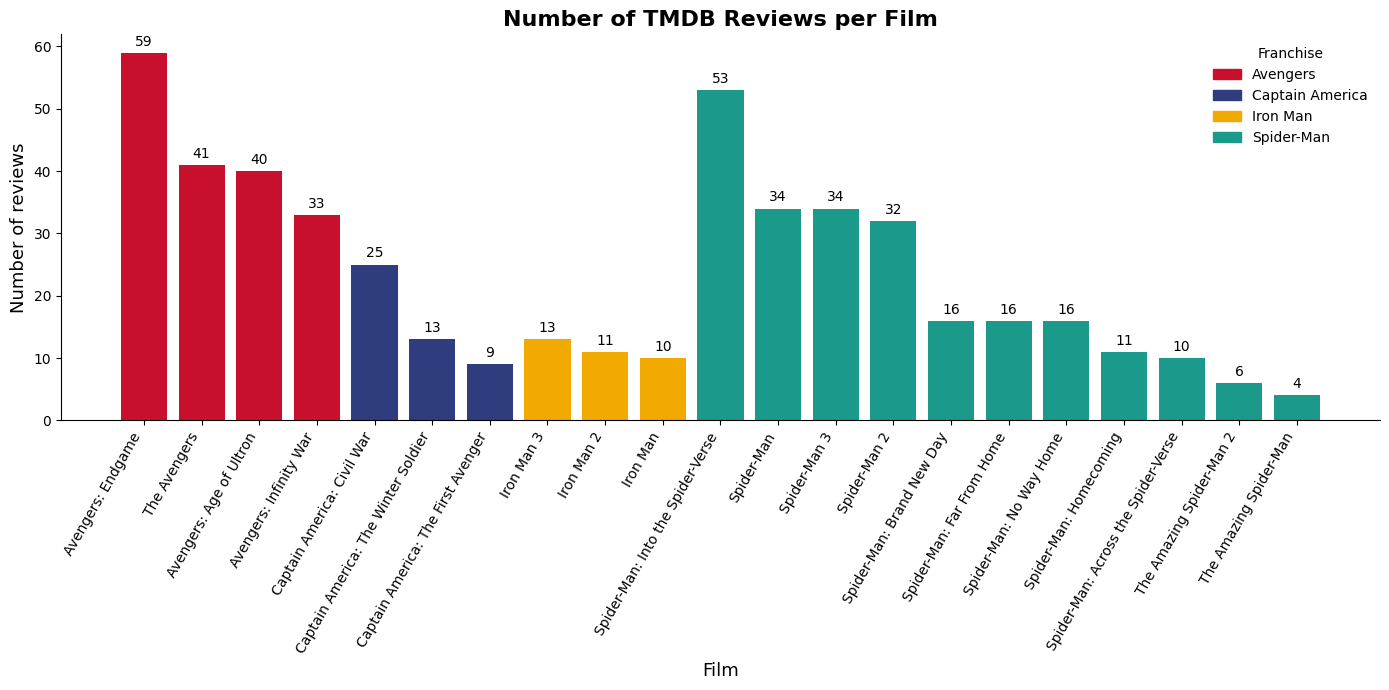

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load the raw review data (run from the repository root)
df = pd.read_csv("/Users/haero/DS4002/DS-4002-Project-1/DATA/marvel_movie_reviews.csv")

# Count reviews per film, keeping each film's franchise for coloring
counts = (
    df.groupby(["movie", "franchise"])
      .size()
      .reset_index(name="n_reviews")
      .sort_values(["franchise", "n_reviews"], ascending=[True, False])
)

# One color per franchise
colors = {
    "Avengers": "#C8102E",
    "Captain America": "#2F3C7E",
    "Iron Man": "#F2A900",
    "Spider-Man": "#1B998B",
}

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(counts["movie"], counts["n_reviews"],
              color=counts["franchise"].map(colors))

# Label each bar with its count
ax.bar_label(bars, padding=3, fontsize=10)

ax.set_title("Number of TMDB Reviews per Film", fontsize=16, weight="bold")
ax.set_xlabel("Film", fontsize=13)
ax.set_ylabel("Number of reviews", fontsize=13)
plt.xticks(rotation=60, ha="right", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

ax.legend(handles=[Patch(color=c, label=f) for f, c in colors.items()],
          title="Franchise", frameon=False)

plt.tight_layout()
plt.savefig("/Users/haero/DS4002/DS-4002-Project-1/OUTPUT/14_reviews_per_film.png", dpi=300)
plt.show()